<a href="https://colab.research.google.com/github/alscop/ESAA-26-1/blob/main/ESAA_OB_week11_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> 딥러닝 파이토치 교과서 7장 p.417-440

## 7.6 게이트 순환 신경망(GRU)

- 게이트 메커니즘이 적용된 RNN 프레임워크의 한 종류  
- LSTM보다 간단한 구조

### 7.6.1 GRU 구조

LSTM에서 시용하는 망각 게이트와 입력 게이트를 하나로 합친 것  
별도의 업데이트 게이트로 구성됨

- 하나의 게이트 컨트롤러 (gate controller) 가 망각 게이트와 입력 게이트를 모두 제어
- 게이트 컨트롤러가 1을 출력하면 망각 게이트는 열리고 입력 게이트는 닫힘
- 반대로 0을 출력하면 망각 게이트는 닫히고 입력 게이트는 열림

즉 이전 기억이 저장될 때마다 단계별 입력은 삭제됨

- 출력 게이트가 없어 전체 상태 벡터가 매 단계마다 출력
- 이전 상태의 어느 부분이 출력될지 제어하는 새로운 게이트 컨트롤러가 별도 존재


#### 망각 게이트

- 과거 정보를 적당히 초기화(rcset) 시키려는 목적
- 시그모이드 함수를 출력으로 이용하여 (0,1) 값을 이전 은닉층에 곱함


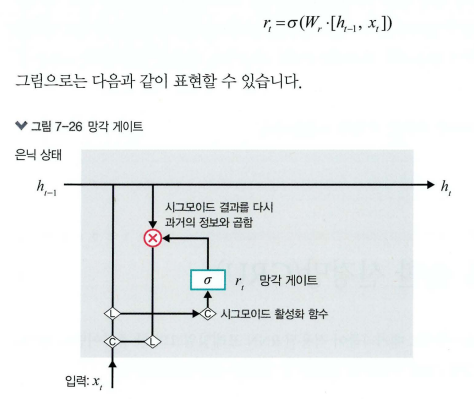

#### 업데이트 게이트

- 과거와 현재 정보의 최선화 비율을 결정
- 시그모이드로 출력된 결과(z1)는 현시점의 정보량을 결정, 1에서 뺀 (l-z1)을 직전 시점의 은닉층 정보와 곱함

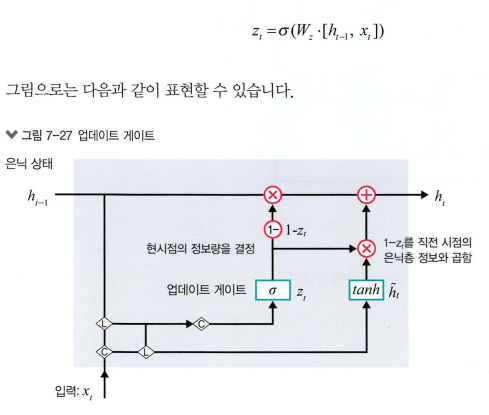

#### 후보군

- 현시점의 정보에 대한 후보군을 계산  
- 과거 은닉층의 정보를 그대로 이용하지 않고 망각 게이트의 결과를 이용하여 계산

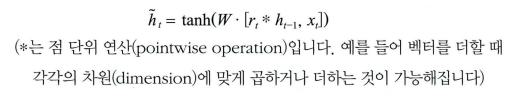

#### 은닉층 계산

- 업데이트 게이트 결과와 후보군 결과를 결합하여 현시점의 은닉층을 계산
- 시그모이드 함수의 결과는 현시점에서 결과에 대한 정보량을 결정하고, 1-시그모이드 함수의 결과는 과거의 정보량 결정

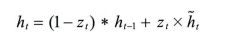




> GRU 전체에 대한 내부 구조

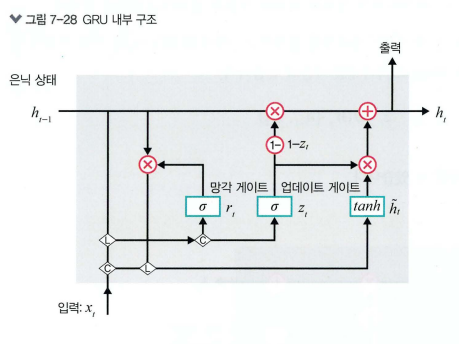

### 7.6.2 GRU 셀 구현

네트워크의 차이점 위주로 학습하자!


In [29]:
# 라이브러리 호출

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
cuda = True if torch.cuda.is_available() else False
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(125)

In [2]:
# 데이터 전처리
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,))
])

평균, 표준편차 기준 정규화  
텐서로 변경

In [3]:
# 데이터셋 내려받기 및 전처리 적용
from torchvision.datasets import MNIST
download_root = '../chap07/MNIST_DATASET'

train_dataset = MNIST(download_root, transform=mnist_transform, train=True,
                      download=True)
valid_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                      download=True)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                      download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.19MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.97MB/s]


In [30]:
# 데이터셋 메모리로 가져오기
batch_size = 64
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
valid_loader = DataLoader(dataset=test_dataset,
                          batch_size=batch_size,
                          shuffle=True)  # 일반적으로 검증/테스트용 데이터셋 섞어서 사용 안함. 예제에서만 다양한 학습을 위해 True로 지정
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         shuffle=True)

데이터로더 이용.  
단 메모리로 불러오는 시점은 각각이 호출되는 시점

In [5]:
# 변수 값 설정
batch_size = 100
n_iters = 6000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

In [32]:
# GRU 셀 네트워크
class GRUCell(nn.Module):
  def __init__(self, input_size, hidden_size, bias=True):
    super(GRUCell, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias
    self.x2h = nn.Linear(input_size, 3 * hidden_size, bias=bias)  # LSTM:4, GRU:3 - 세 개의 게이트 사용되므로.
    self.h2h = nn.Linear(hidden_size, 3 * hidden_size, bias=bias)
    self.reset_parameters()

  def reset_parameters(self):  # 파라미터 초기화
    std = 1.0 / math.sqrt(self.hidden_size)  # hidden size에 따라 적당한 범위에서 초기화
    for w in self.parameters():
      w.data.uniform_(-std, std)

  def forward(self, x, hidden):
    x = x.view(-1, x.size(1))

    # 각각 선형변환
    gate_x = self.x2h(x)  # GRU 셀에서는 개별적 상태 유지
    gate_h = self.h2h(hidden)
    gate_x = gate_x.squeeze()
    gate_h = gate_h.squeeze()

    # 총 세 개의 게이트(망각/입력/새로운 게이트)를 위해 세 개로 쪼갬
    i_r, i_i, i_n = gate_x.chunk(3,1)
    h_r, h_i, h_n = gate_h.chunk(3,1)

    resetgate = F.sigmoid(i_r + h_r)
    inputgate = F.sigmoid(i_i + h_i)
    newgate = F.tanh(i_n + (resetgate * h_n))   # 새로운 게이트는 탄젠트 활성화함수가 적용된 게이트

    hy = newgate + inputgate + (hidden - newgate)
    return hy

In [33]:
# 전반적인 네트워크 구조
class GRUModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias = True):
    super(GRUModel, self).__init__()
    self.hidden_dim = hidden_dim
    self.layer_dim = layer_dim

    self.gru_cell = GRUCell(input_dim, hidden_dim, layer_dim)  # 앞에서 정의한 GRUCell 함수 불러오기
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    if torch.cuda.is_available():
      h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
    else:
      h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

    outs = []
    hn = h0[0,:,:]  # LSTM: 셀 상태도 정의. GRU: 셀 사용되지 않음

    for seq in range(x.size(1)):
      hn = self.gru_cell(x[:,seq,:], hn)
      outs.append(hn)
      out = outs[-1].squeeze()
      out = self.fc(out)
      return out

In [8]:
# 옵티마이저와 손실 함수 설정
input_dim = 28
hidden_dim = 128
layer_dim = 1
output_dim = 10

model = GRUModel(input_dim, hidden_dim, layer_dim, output_dim)

if torch.cuda.is_available():
  model.cuda()

criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [9]:
# 모델 학습 및 성능 검증
seq_dim = 28
loss_list = []
iter = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images = Variable(images.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            images = Variable(images.view(-1, seq_dim, input_dim))
            lables = Variable(labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % 500 == 0:
            correct = 0
            total = 0
            for images, labels in valid_loader:
                if torch.cuda.is_available():
                    images = Variable(images.view(-1, seq_dim, input_dim).cuda())
                else:
                    images = Variable(images.view(-1, seq_dim, input_dim))

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == lables.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct / total
            print('Iteration:{}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration:500. Loss: 2.3189640045166016. Accuracy: 9.800000190734863
Iteration:1000. Loss: 2.3267130851745605. Accuracy: 10.100000381469727
Iteration:1500. Loss: 2.3228468894958496. Accuracy: 11.350000381469727
Iteration:2000. Loss: 2.297893762588501. Accuracy: 10.09000015258789
Iteration:2500. Loss: 2.2895259857177734. Accuracy: 11.350000381469727
Iteration:3000. Loss: 2.3024449348449707. Accuracy: 9.819999694824219
Iteration:3500. Loss: 2.3391358852386475. Accuracy: 11.350000381469727
Iteration:4000. Loss: 2.3217453956604004. Accuracy: 9.819999694824219
Iteration:4500. Loss: 2.353975772857666. Accuracy: 11.350000381469727
Iteration:5000. Loss: 2.3270187377929688. Accuracy: 10.279999732971191
Iteration:5500. Loss: 2.322566032409668. Accuracy: 11.350000381469727
Iteration:6000. Loss: 2.3192501068115234. Accuracy: 9.819999694824219
Iteration:6500. Loss: 2.3150668144226074. Accuracy: 9.739999771118164
Iteration:7000. Loss: 2.336620330810547. Accuracy: 11.350000381469727
Iteration:7500. L

LSTM과 모델 학습, 성능 측정 과정은 동일  

LSTM과 GRU 정확도 유사함 - 시계열 처리 모델(RNN, LSTM, GRU) 중 어떤 것이 더 좋다고 말할 수 없음.  



In [10]:
# 테스트 데이터셋을 이용한 모델 예측
def evaluate(model, val_iter):
  corrects, total, total_loss = 0,0,0
  model.eval()
  for images, labels in val_iter:
    if torch.cuda.is_available():
      images = Variable(images.view(-1, seq_dim, input_dim).cuda())
    else:
      images = Variable(images.view(-1, seq_dim, input_dim)).to(device)

    logit = model(images).to(device)
    loss = F.cross_entropy(logit, labels, reduction='sum')
    _, predicted = torch.max(logit.data, 1)
    total += labels.size(0)
    total_loss += loss.item()
    corrects += (predicted == labels).sum()

  avg_loss = total_loss / len(val_iter.dataset)
  avg_accuracy = corrects / total
  return avg_loss, avg_accuracy

In [13]:
# 모델 예측 결과
test_loss, test_acc = evaluate(model, test_loader)
print("Test Loss: %5.2f | Test Accuracy: %5.2f" % (test_loss, test_acc))

Test Loss:  2.31 | Test Accuracy:  0.10


예측력이 왜이렇게 낮지 ... ?  
원래는 LSTM과 성능 비슷해야됨 .

데이터셋에 따라 정확도 다르게 나올 수 있으므로, 다양한 모델 적용 후 최적 하이퍼파라미터 찾는 것이 중요

### 7.6.3 GRU 계층 구현

마찬가지로 네트워크 위주 학습

In [14]:
# 라이브러리 호출
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [15]:
!git clone https://github.com/gilbutITbook/080289.git
data_path = './080289/chap07/data/SBUX.csv'
data = pd.read_csv(data_path)

print(data.dtypes)

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 26.16 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [16]:
# 인덱스 설정 및 데이터 타입 변경
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data['Volume'] = data['Volume'].astype(float)

대소문자 구분 잘하기  

칼럼 인덱스 지정  
volume 칼럼 데이터 형식을 변경

In [34]:
# 훈련과 레이블 데이터셋 분리
X = data.iloc[:, :-1]  # 전체 칼럼 중 마지막 칼럼 제외한 모든 데이터셋 - 훈련 용도
y = data.iloc[:, 5:6]  # 마지막칼럼 레이블로 지정
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

In [18]:
# 훈련과 테스트 데이터셋 정규화
ms = MinMaxScaler()
ss = StandardScaler()

X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

X_train = X_ss[:200, :]
X_test = X_ss[200:, :]

y_train = y_ms[:200, :]
y_test = y_ms[200:, :]

print("Training Shape", X_train.shape, y_train.shape)
print("Testing Shape", X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


정규화, 분포 조정

In [19]:
# 데이터셋 형태 변경
X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0], 1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[0], 1, X_test_tensors.shape[1]))

print("Training Shape", X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape", X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


LSTM 네트워크에 적용하기 위해 변경함

In [35]:
# GRU 모델의 네트워크
class GRU(nn.Module):
  def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
    super(GRU, self).__init__()
    self.num_classes = num_classes
    self.num_layers = num_layers
    self.hidden_size = hidden_size
    self.seq_length = seq_length

    self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                      num_layers=num_layers, batch_first = True)
    self.fc_1 = nn.Linear(hidden_size, 128)
    self.fc = nn.Linear(128, num_classes)
    self.relu = nn.ReLU()

  def forward(self, x):
    h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
    #  ^ 은닉 상태에 대해 0으로 초기화. LSTM: 셀 상태 有, GRU: 셀 상태 정의 X
    output, (hn) = self.gru(x, (h_0))
    hn = hn.view(-1, self.hidden_size)
    out = self.relu(hn)
    out = self.fc_1(out)
    out = self.relu(out)
    out = self.fc(out)
    return out

In [21]:
# 옵티마이저와 손실 함수 지정
num_epochs = 1000
learning_rate = 0.0001

input_size = 5
hidden_size = 2
num_layers = 1

num_classes = 1
model = GRU(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [22]:
# 모델 학습
for epoch in range(num_epochs):
  outputs = model.forward(X_train_tensors_f)
  optimizer.zero_grad()
  loss = criterion(outputs, y_train_tensors)
  loss.backward()

  optimizer.step()
  if epoch % 100 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.11692
Epoch: 100, loss: 0.04124
Epoch: 200, loss: 0.03291
Epoch: 300, loss: 0.03008
Epoch: 400, loss: 0.02830
Epoch: 500, loss: 0.02701
Epoch: 600, loss: 0.02590
Epoch: 700, loss: 0.02486
Epoch: 800, loss: 0.02385
Epoch: 900, loss: 0.02284


In [23]:
# 그래프 출력 위한 전처리
df_x_ss = ss.transform(data.iloc[:, :-1])
df_y_ms = ms.transform(data.iloc[:, -1:])

df_x_ss = Variable(torch.Tensor(df_x_ss))
df_y_ms = Variable(torch.Tensor(df_y_ms))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

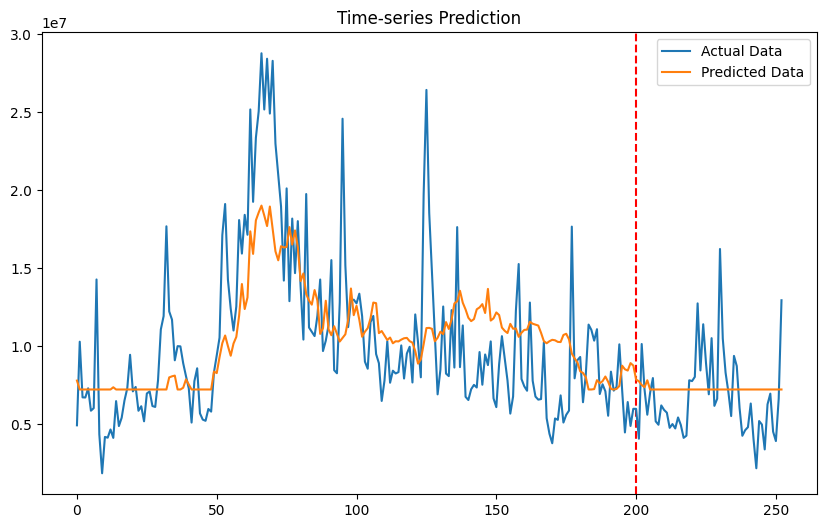

In [24]:
# 모델 예측 결과 출력
train_predict = model(df_x_ss)
predicted = train_predict.data.numpy()
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform(predicted)
label_y = ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200, c='r', linestyle='--')

plt.plot(label_y, label='Actual Data')
plt.plot(predicted, label='Predicted Data')
plt.title('Time-series Prediction')
plt.legend()
plt.show()

그래프상 GRU가 LSTM보다 예측력 더 좋아보임.  
BUT 수치상으로 예측 정확도 거의 유사.  
훈련 데이터 섞어서 결과 매번 달라질 수 있음!

## 7.7 양방향 RNN

RNN은 이전 시점 데이터 참고해서 정답 예측.  
실제문제: 과거시점 말고 미래시점에 힌트가 있기도함.

### 7.7.1 양방향 RNN 구조


- 하나의 출력 값을 예측하는 데 메모리 셀 두 개를 사용
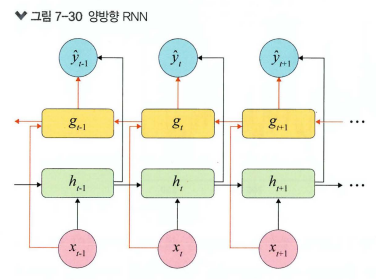
1. 첫 번째 메모리 셀: 이전 시점의 은닉 상태를 전달받아 현재의 은닉 상태를 계산.   (그림: 초록색 메모리 셀)
2. 두 번째 메모리 셀: 다음 시점의 은닉 상태를 전달받아 현재의 은닉 상태를 계산.
(그림: 노란색 메모리 셀)
- 이 값 두 개를 모두 출력층에서 출력 값을 예측하는 데 사용




### 7.7.2 양방향 LSTM 구현

> 스타벅스 주가 예측 데이터셋 사용 예제

In [25]:
# 모델을 생성하고 학습
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

data_path = './080289/chap07/data/SBUX.csv'
data = pd.read_csv(data_path)

print(data.dtypes)

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data['Volume'] = data['Volume'].astype(float)

X = data.iloc[:, :-1]
y = data.iloc[:, 5:6]

ms = MinMaxScaler()
ss = StandardScaler()

X_ss = ms.fit_transform(X)
y_ms = ss.fit_transform(y)

X_train = X_ss[:200, :]
X_test = X_ss[200:, :]

y_train = y_ms[:200, :]
y_test = y_ms[200:, :]

X_train_tensors = Variable(torch.Tensor(X_train))
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0], 1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[0], 1, X_test_tensors.shape[1]))

print("Training Shape", X_train_tensors_f.shape, y_train_tensors.shape)
print("Testing Shape", X_test_tensors_f.shape, y_test_tensors.shape)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


> 네트워크 부분에 집중!

In [26]:
# 모델의 네트워크
class biLSTM(nn.Module):
  def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
    super(biLSTM, self).__init__()
    self.num_classes = num_classes
    self.num_layers = num_layers
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.seq_length = seq_length

    self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, bidirectional=True, batch_first=True)
    self.fc = nn.Linear(hidden_size*2, num_classes)
    self.relu = nn.ReLU()

  def forward(self, x):
    h_0 = Variable(torch.zeros(self.num_layers*2, x.size(0), self.hidden_size))
    c_0 = Variable(torch.zeros(self.num_layers*2, x.size(0), self.hidden_size))
    out, (hn, cn) = self.lstm(x, (h_0, c_0))
    out = self.fc(out[:,-1,:])
    out = self.relu(out)
    return out

- 계층 정의(nn.LSTM)에 bidirectional=True 옵션: 양방향 LSTM 사용하겠다는 의미
- hidden_size*2, self.num_layers*2: 한 번 학습에 2개의 계층 필요해서 LSTM과 달리 은닉 상태, 셀 상태에 2를 곱함.

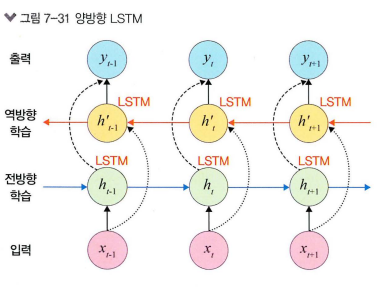

In [27]:
# 모델 학습
num_epochs = 1000
learning_rate = 0.0001

input_size = 5
hidden_size = 2
num_layers = 1
num_classes = 1
model = biLSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
  outputs = model.forward(X_train_tensors_f)
  optimizer.zero_grad()

  loss = criterion(outputs, y_train_tensors)
  loss.backward()
  optimizer.step()
  if epoch % 100 ==0:
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 1.13298
Epoch: 100, loss: 1.11972
Epoch: 200, loss: 1.10750
Epoch: 300, loss: 1.09623
Epoch: 400, loss: 1.08583
Epoch: 500, loss: 1.07628
Epoch: 600, loss: 1.06754
Epoch: 700, loss: 1.05955
Epoch: 800, loss: 1.05221
Epoch: 900, loss: 1.04539


값은 줄어들지만 얼마나 훈련이 잘 된건지 알기는 어려움.  
-> 그래프로 모델 예측력 살펴보기 .

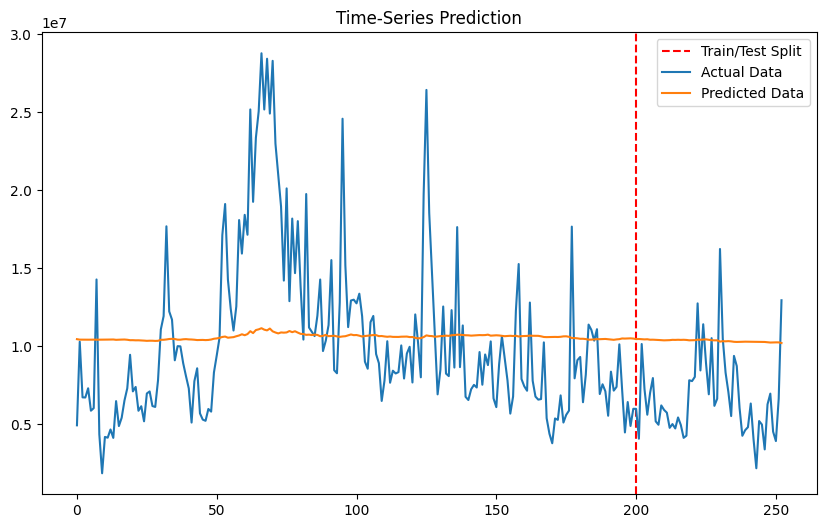

In [28]:
# 모델 평가
df_x_ms = ms.transform(data.iloc[:,:-1])
df_y_ss = ss.transform(data.iloc[:,-1:])

df_x_ms = Variable(torch.Tensor(df_x_ms))
df_y_ss = Variable(torch.Tensor(df_y_ss))
df_x_ms = torch.reshape(df_x_ms, (df_x_ms.shape[0], 1, df_x_ms.shape[1]))

train_predict = model(df_x_ms.to(device))
predicted = train_predict.detach().cpu().numpy()
label_y = df_y_ss.cpu().numpy()

predicted = ss.inverse_transform(predicted)
label_y = ss.inverse_transform(label_y)
plt.figure(figsize=(10, 6))
plt.axvline(x=200, color='r', linestyle='--', label='Train/Test Split')

plt.plot(label_y, label="Actual Data")
plt.plot(predicted, label="Predicted Data")

plt.title("Time-Series Prediction")
plt.legend()
plt.show()

그래프가 너무 못생김 ... 뭔가 잘못됨 ...

원래는 두 개가 유사해서 LSTM보다 예측 결과가 좋다고 봐야함